<a href="https://colab.research.google.com/github/krithikasanga/capestone_projects_ml/blob/main/gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_regression

# make_regression is used to generate a fake (synthetic) dataset
# for regression problems (i.e., predicting continuous values)

X, y = make_regression(

    n_samples=4,
    # Total number of data points (rows)
    # Here, only 4 data points are created (very small dataset)

    n_features=1,
    # Number of input features (columns in X)
    # Here, only 1 independent variable (like x in y = mx + c)

    n_informative=1,
    # Number of useful features that actually affect the output
    # Since we only have 1 feature, it is informative

    n_targets=1,
    # Number of output variables (y)
    # 1 means single output (normal regression)

    noise=50,
    # Adds randomness (error) to the data
    # Higher value = more noisy / less perfect data
    # Makes it closer to real-world messy data

    random_state=13
    # Fixes randomness so you get the same data every time you run the code
    # Useful for reproducibility
)

# X -> Input data (features)
# y -> Output data (target values)

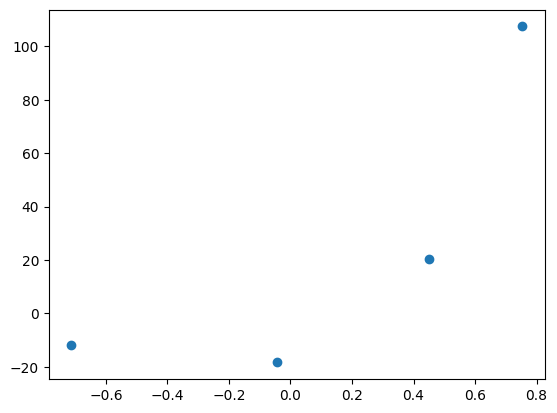

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(X,y)

lets apply Ols

In [ ]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X,y)

LinearRegression()

In [ ]:
reg.predict(X)


array([-34.80574931,  48.79361951,  13.15408278,  70.47640776])

In [ ]:
b=reg.intercept_
b

np.float64(16.34977052695789)

In [ ]:
coef=reg.coef_
coef

array([71.80824028])

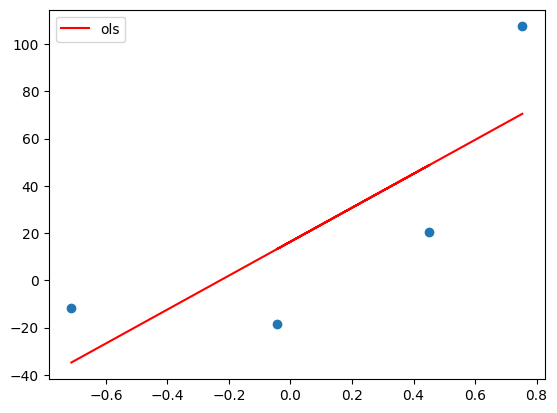

In [ ]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='ols')
plt.legend()

start with a random value of b(b=0) asuume that m is known from ols

***b new= b old - step_size***


***step_size=  lr*(slope)***



lr=learning rate initially 0.1 or 0.01
slope is the slope of the curve at that point
## loss function l(m,b)

$$
l =  \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

this is the loss function since y=mx+b so hence agn the loss function would be $$
l = \sum_{i=1}^{n} (y_i - (mx_i + b))^2
$$
we differenciate the above loss function we will get $$
\frac{d}{db} \left( \sum_{i=1}^{n} (y_i - (mx_i + b))^2 \right)
= -2 \sum_{i=1}^{n} \big(y_i - m x_i - b\big)
$$
calcalate the slope by substituting b and m

In [ ]:
m=coef[0]
m

np.float64(71.80824027821977)

In [ ]:
b=0

In [ ]:
#iteration one taking b=0 and m is known from ols m=71.80
y_pred=(71.808*X+0).reshape(4)

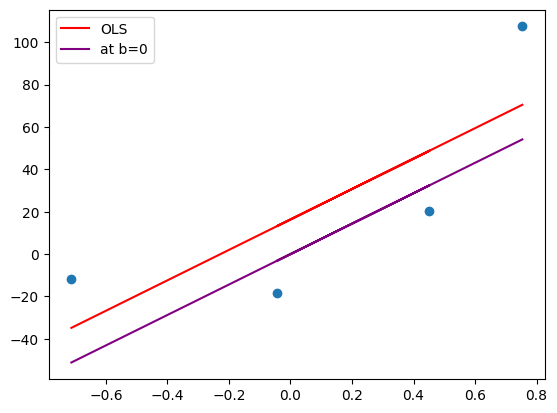

In [ ]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='purple',label='at b=0')
plt.legend()
plt.show()

$$ -2 \sum_{i=1}^{n} \big(y_i - m x_i - b\big) $$

In [ ]:
loss_slope=-2*np.sum(y-m*X.ravel()-b)#.ravel() is a NumPy function that converts an array into a 1D (flattened) array x conists 4 points so its gnna flatten it
loss_slope


np.float64(-130.79816421566312)

In [ ]:
#taking learning rate as 0.1
#step size= lr*slope
lr=0.01
step_size=lr*loss_slope
step_size

np.float64(-1.3079816421566313)

In [ ]:
b=b-step_size
b

np.float64(1.3079816421566313)

In [ ]:
y_pred1=(71.808*X+b).reshape(4)
y_pred1

array([-49.84736702,  33.75172206,  -1.88769541,  55.43443776])

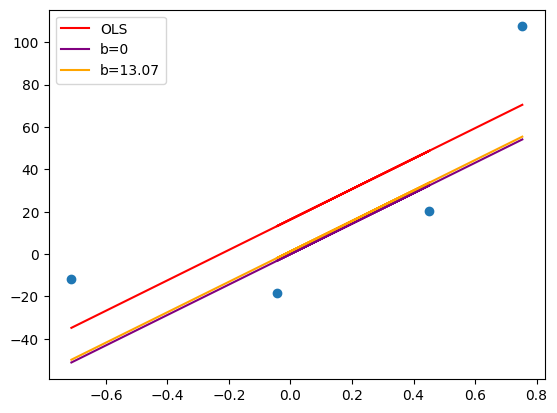

In [ ]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color='purple',label="b=0")
plt.plot(X,y_pred1,color='orange',label="b=13.07")
plt.legend()

In [ ]:
#iteration 2
m

np.float64(71.80824027821977)

In [ ]:
b

np.float64(1.3079816421566313)

In [ ]:
loss_slope=-2*np.sum(y+m*X.ravel()-b)

step_size=lr*loss_slope
step_size

np.float64(-2.492114256338244)

In [ ]:
b=b-step_size
b

np.float64(3.800095898494875)

In [ ]:
y_pred2=(71.808*X+b).reshape(4)
y_pred2

array([-47.35525276,  36.24383632,   0.60441885,  57.92655202])

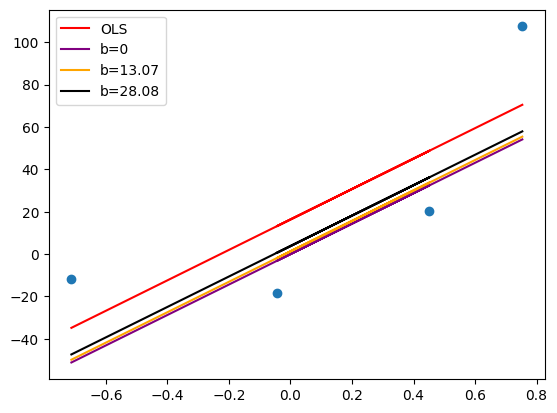

In [ ]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color='purple',label="b=0")
plt.plot(X,y_pred1,color='orange',label="b=13.07")
plt.plot(X,y_pred2,color='black',label="b=28.08")
plt.legend()

In [ ]:
b

np.float64(3.800095898494875)

In [ ]:
loss_slope=-2*np.sum(y+m*X.ravel()-b)

step_size=lr*loss_slope
step_size

np.float64(-2.2927451158311842)

In [ ]:
b=b-step_size
b

np.float64(6.092841014326059)

In [ ]:
y_pred3=(71.808*X+b).reshape(4)
y_pred3

array([-45.06250765,  38.53658143,   2.89716397,  60.21929713])

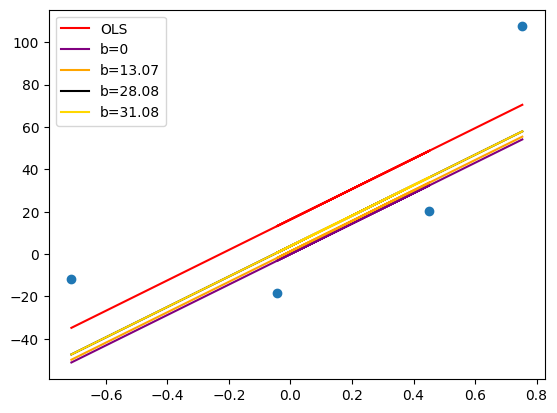

In [ ]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color='purple',label="b=0")
plt.plot(X,y_pred1,color='orange',label="b=13.07")
plt.plot(X,y_pred2,color='black',label="b=28.08")
plt.plot(X,y_pred2,color='gold',label="b=31.08")
plt.legend()

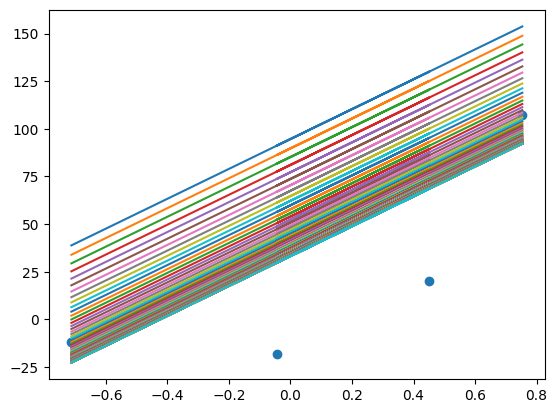

In [ ]:
b=100
m=78.35
lr=0.01
epochs=100
for i in range(epochs):
  loss_slope=-2*np.sum(y+m*X.ravel()-b)
  b=b-(lr*loss_slope)
  y_p=m*X+b
  plt.plot(X,y_p)
plt.scatter(X,y)